## IMPORT LIBRARY

In [10]:
!pip install -q pyspark kaggle wordcloud

In [11]:
# ===== IMPORT =====
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression, NaiveBayes
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


## SETUP KAGGLE API DAN DOWNLOAD DATASET

In [12]:
os.environ['KAGGLE_API_TOKEN'] = "TOKEN_KAMU_DI_SINI"

!mkdir -p ~/.kaggle
!echo '{"token":"TOKEN_KAMU_DI_SINI"}' > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

print("Kaggle API siap!")

Kaggle API siap!


In [13]:
print("Mengunduh dataset Yelp Review dari Kaggle...")
!kaggle datasets download -d yelp-dataset/yelp-dataset \
    -f yelp_academic_dataset_review.json

print("\nMengekstrak file...")
!unzip -o yelp_academic_dataset_review.json.zip

file_path = "yelp_academic_dataset_review.json"
size_gb = os.path.getsize(file_path) / (1024 ** 3)
print(f"\nFile berhasil didownload!")
print(f"Ukuran file  : {size_gb:.2f} GB")
print(f"Lokasi file  : {file_path}")

Mengunduh dataset Yelp Review dari Kaggle...
Dataset URL: https://www.kaggle.com/datasets/yelp-dataset/yelp-dataset
License(s): other
yelp_academic_dataset_review.json.zip: Skipping, found more recently modified local copy (use --force to force download)

Mengekstrak file...
Archive:  yelp_academic_dataset_review.json.zip
  inflating: yelp_academic_dataset_review.json  

File berhasil didownload!
Ukuran file  : 4.98 GB
Lokasi file  : yelp_academic_dataset_review.json


## INISIALISASI PYSPARK DAN LOAD DATA

In [14]:
spark = SparkSession.builder \
    .appName("YelpSentimentAnalysis") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

print(f"Spark Version : {spark.version}")

# Load dataset JSON dengan PySpark
print("\nMemuat dataset dengan PySpark...")
df_raw = spark.read.json(file_path)

# Verifikasi data
print(f"\nTotal reviews : {df_raw.count():,}")
print("\nSchema:")
df_raw.printSchema()
print("\n5 data pertama:")
df_raw.show(5, truncate=50)

Spark Version : 4.0.2

Memuat dataset dengan PySpark...

Total reviews : 6,990,280

Schema:
root
 |-- business_id: string (nullable = true)
 |-- cool: long (nullable = true)
 |-- date: string (nullable = true)
 |-- funny: long (nullable = true)
 |-- review_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- text: string (nullable = true)
 |-- useful: long (nullable = true)
 |-- user_id: string (nullable = true)


5 data pertama:
+----------------------+----+-------------------+-----+----------------------+-----+--------------------------------------------------+------+----------------------+
|           business_id|cool|               date|funny|             review_id|stars|                                              text|useful|               user_id|
+----------------------+----+-------------------+-----+----------------------+-----+--------------------------------------------------+------+----------------------+
|XQfwVwDr-v0ZS3_CbbE5Xw|   0|2018-07-07 22:09:11| 

## PREPROCESSING DAN LABELING

In [15]:
# Pilih kolom yang diperlukan
df = df_raw.select("review_id", "stars", "text", "date", "useful", "funny", "cool")

# Buang rating netral (bintang 3)
df_filtered = df.filter(F.col("stars") != 3)

# Buat label sentimen binary
# Bintang 4-5 = Positif (1), Bintang 1-2 = Negatif (0)
df_labeled = df_filtered.withColumn(
    "label",
    F.when(F.col("stars") >= 4, 1).otherwise(0)
)

# Buang baris dengan text kosong atau terlalu pendek
df_clean = df_labeled.dropna(subset=["text", "stars"])
df_clean = df_clean.filter(F.length(F.col("text")) > 10)

# Tampilkan distribusi label
print("Distribusi label sentimen:")
df_clean.groupBy("label").count().show()

print(f"\nTotal data setelah cleaning: {df_clean.count():,}")
print("\n5 data setelah labeling:")
df_clean.select("stars", "label", "text").show(5, truncate=60)

Distribusi label sentimen:
+-----+-------+
|label|  count|
+-----+-------+
|    1|4684444|
|    0|1613735|
+-----+-------+


Total data setelah cleaning: 6,298,179

5 data setelah labeling:
+-----+-----+------------------------------------------------------------+
|stars|label|                                                        text|
+-----+-----+------------------------------------------------------------+
|  5.0|    1|I've taken a lot of spin classes over the years, and noth...|
|  5.0|    1|Wow!  Yummy, different,  delicious.   Our favorite is the...|
|  4.0|    1|Cute interior and owner (?) gave us tour of upcoming pati...|
|  1.0|    0|I am a long term frequent customer of this establishment....|
|  5.0|    1|Loved this tour! I grabbed a groupon and the price was gr...|
+-----+-----+------------------------------------------------------------+
only showing top 5 rows


## TRAINING MODEL

In [16]:
tokenizer  = Tokenizer(inputCol="text", outputCol="words")
remover    = StopWordsRemover(inputCol="words", outputCol="filtered_words")
hashingTF  = HashingTF(inputCol="filtered_words", outputCol="rawFeatures", numFeatures=10000)
idf        = IDF(inputCol="rawFeatures", outputCol="features")

# Model 1: Logistic Regression
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=10,
    regParam=0.1
)

# Model 2: Naive Bayes
nb = NaiveBayes(
    featuresCol="features",
    labelCol="label",
    smoothing=1.0
)

# Rangkai pipeline
pipeline_lr = Pipeline(stages=[tokenizer, remover, hashingTF, idf, lr])
pipeline_nb = Pipeline(stages=[tokenizer, remover, hashingTF, idf, nb])

# Split data 80% train, 20% test
train_data, test_data = df_clean.randomSplit([0.8, 0.2], seed=42)

print(f"Data training : {train_data.count():,}")
print(f"Data testing  : {test_data.count():,}")

# Training kedua model
print("Melatih Model 1: Logistic Regression...")
model_lr = pipeline_lr.fit(train_data)
print("Model 1 selesai!")

print("\nMelatih Model 2: Naive Bayes...")
model_nb = pipeline_nb.fit(train_data)
print("Model 2 selesai!")

Data training : 5,037,056
Data testing  : 1,261,123
Melatih Model 1: Logistic Regression...
Model 1 selesai!

Melatih Model 2: Naive Bayes...
Model 2 selesai!


## EVALUASI MODEL

In [17]:
predictions_lr = model_lr.transform(test_data)
predictions_nb = model_nb.transform(test_data)

def evaluate_model(predictions, model_name):
    auc = BinaryClassificationEvaluator(
        labelCol="label",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    ).evaluate(predictions)

    accuracy = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="accuracy"
    ).evaluate(predictions)

    f1 = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="f1"
    ).evaluate(predictions)

    precision = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedPrecision"
    ).evaluate(predictions)

    recall = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName="weightedRecall"
    ).evaluate(predictions)

    print(f"\n{'=' * 45}")
    print(f"   HASIL EVALUASI: {model_name}")
    print(f"{'=' * 45}")
    print(f"AUC-ROC            : {auc:.4f}")
    print(f"Akurasi            : {accuracy * 100:.2f}%")
    print(f"F1-Score           : {f1:.4f}")
    print(f"Weighted Precision : {precision:.4f}")
    print(f"Weighted Recall    : {recall:.4f}")
    print(f"{'=' * 45}")

    return {
        "model": model_name,
        "auc": auc,
        "accuracy": accuracy,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

result_lr = evaluate_model(predictions_lr, "Logistic Regression")
result_nb = evaluate_model(predictions_nb, "Naive Bayes")


   HASIL EVALUASI: Logistic Regression
AUC-ROC            : 0.9778
Akurasi            : 91.95%
F1-Score           : 0.9159
Weighted Precision : 0.9211
Weighted Recall    : 0.9195

   HASIL EVALUASI: Naive Bayes
AUC-ROC            : 0.6238
Akurasi            : 88.79%
F1-Score           : 0.8896
Weighted Precision : 0.8927
Weighted Recall    : 0.8879


## VISUALISASI DAN ANALISIS

Membuat Plot 1: Distribusi rating bintang...


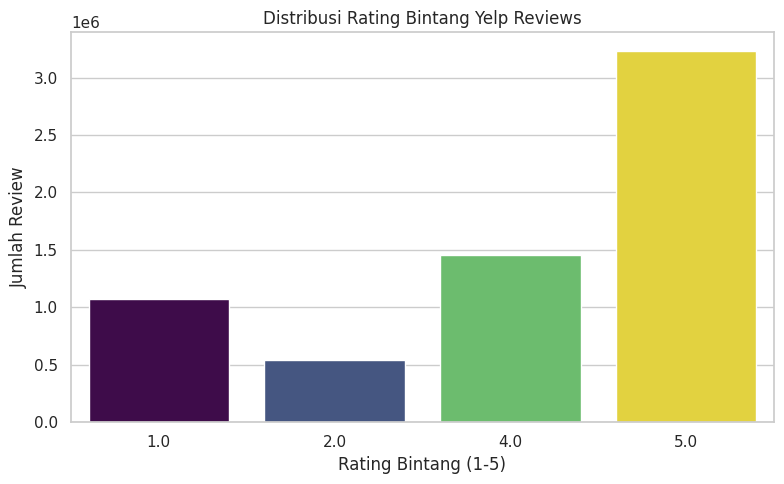

Membuat Plot 2: Proporsi sentimen...


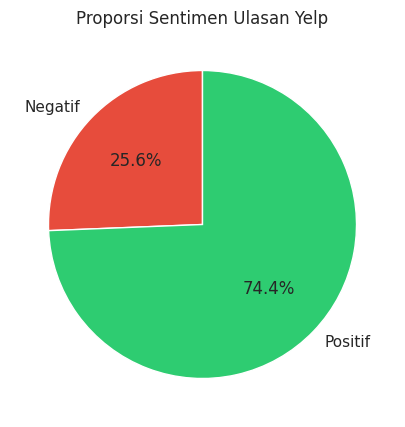

Membuat Plot 3: Panjang review vs sentimen...


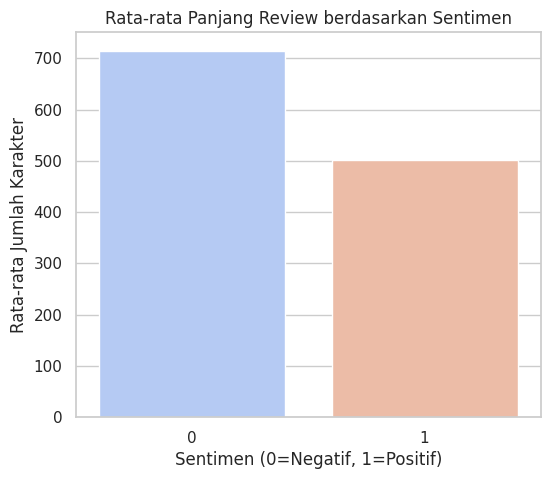

Membuat Plot 4: Tren sentimen per tahun...


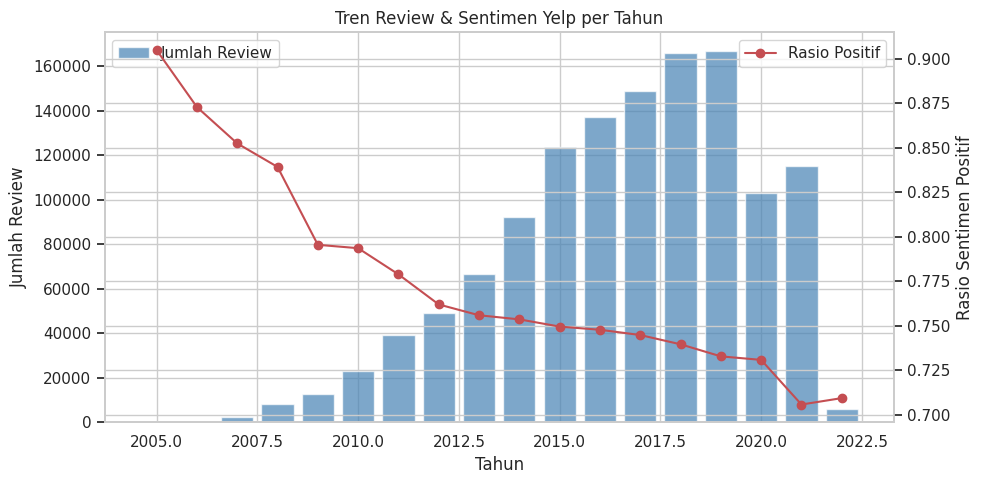

Membuat Plot 5: Word Cloud...


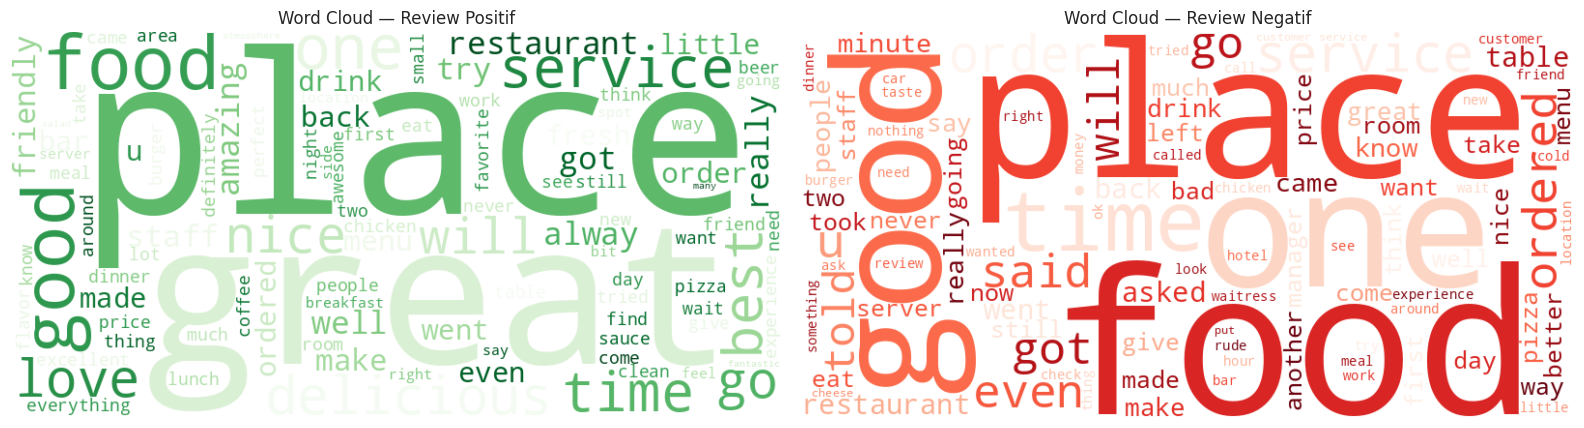

Membuat Plot 6: Perbandingan model...


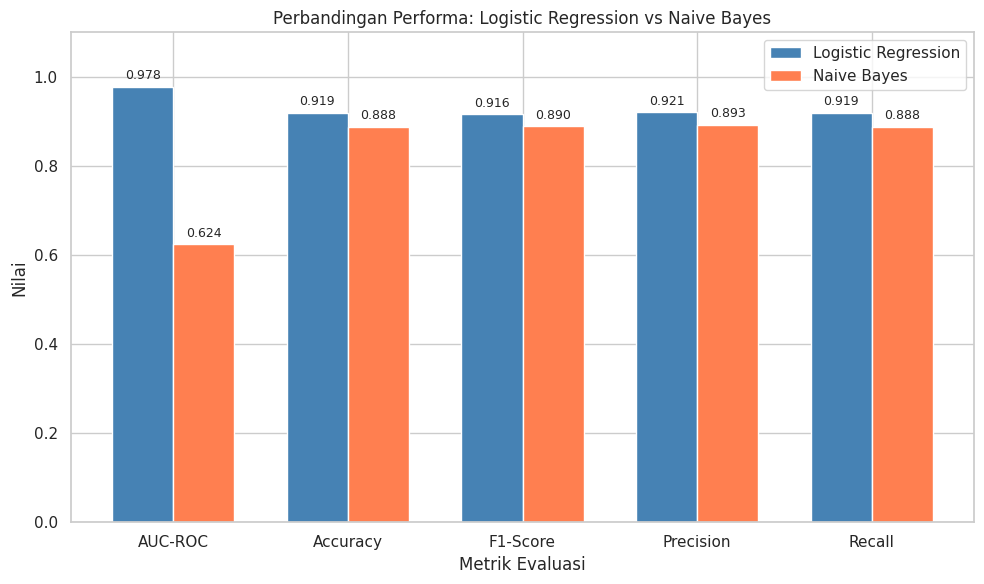


Semua visualisasi selesai!


In [18]:
sns.set_theme(style="whitegrid")

predictions_lr.cache()

# --------------------------------------------------
# Plot 1: Distribusi Rating Bintang
# --------------------------------------------------
print("Membuat Plot 1: Distribusi rating bintang...")
rating_dist = df_clean.groupBy("stars").count().orderBy("stars").toPandas()

plt.figure(figsize=(8, 5))
sns.barplot(data=rating_dist, x="stars", y="count",
            hue="stars", palette="viridis", legend=False)
plt.title("Distribusi Rating Bintang Yelp Reviews")
plt.xlabel("Rating Bintang (1-5)")
plt.ylabel("Jumlah Review")
plt.tight_layout()
plt.savefig("plot1_rating.png", dpi=150)
plt.show()

# --------------------------------------------------
# Plot 2: Proporsi Sentimen
# --------------------------------------------------
print("Membuat Plot 2: Proporsi sentimen...")
sentiment_dist = predictions_lr.groupBy("label").count().toPandas()
sentiment_dist = sentiment_dist.sort_values("label")

plt.figure(figsize=(6, 5))
plt.pie(
    sentiment_dist["count"],
    labels=["Negatif", "Positif"],
    autopct="%1.1f%%",
    colors=["#e74c3c", "#2ecc71"],
    startangle=90
)
plt.title("Proporsi Sentimen Ulasan Yelp")
plt.savefig("plot2_sentimen.png", dpi=150)
plt.show()

# --------------------------------------------------
# Plot 3: Rata-rata Panjang Review vs Sentimen
# --------------------------------------------------
print("Membuat Plot 3: Panjang review vs sentimen...")
predictions_len = predictions_lr.withColumn(
    "review_length", F.length(F.col("text"))
)
length_sentiment = predictions_len.groupBy("label").agg(
    F.avg("review_length").alias("avg_length")
).toPandas()

plt.figure(figsize=(6, 5))
sns.barplot(data=length_sentiment, x="label", y="avg_length",
            hue="label", palette="coolwarm", legend=False)
plt.title("Rata-rata Panjang Review berdasarkan Sentimen")
plt.xlabel("Sentimen (0=Negatif, 1=Positif)")
plt.ylabel("Rata-rata Jumlah Karakter")
plt.savefig("plot3_panjang.png", dpi=150)
plt.show()

# --------------------------------------------------
# Plot 4: Tren Sentimen per Tahun
# --------------------------------------------------
print("Membuat Plot 4: Tren sentimen per tahun...")
predictions_year = predictions_lr.withColumn(
    "year", F.year(F.to_date(F.col("date")))
)
trend = predictions_year.groupBy("year").agg(
    F.avg("label").alias("positive_ratio"),
    F.count("*").alias("total_reviews")
).orderBy("year").toPandas()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(trend["year"], trend["total_reviews"],
        color="steelblue", alpha=0.7, label="Jumlah Review")
ax2 = ax1.twinx()
ax2.plot(trend["year"], trend["positive_ratio"],
         "r-o", label="Rasio Positif")
ax1.set_xlabel("Tahun")
ax1.set_ylabel("Jumlah Review")
ax2.set_ylabel("Rasio Sentimen Positif")
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Tren Review & Sentimen Yelp per Tahun")
plt.tight_layout()
plt.savefig("plot4_tren.png", dpi=150)
plt.show()

# --------------------------------------------------
# Plot 5: Word Cloud Review Positif & Negatif
# --------------------------------------------------
print("Membuat Plot 5: Word Cloud...")
sample_pos = predictions_lr.filter(F.col("label") == 1) \
    .select("text").limit(5000).toPandas()
sample_neg = predictions_lr.filter(F.col("label") == 0) \
    .select("text").limit(5000).toPandas()

pos_text = " ".join(sample_pos["text"].dropna().values)
neg_text = " ".join(sample_neg["text"].dropna().values)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=800, height=400, background_color="white",
                   colormap="Greens", max_words=100).generate(pos_text)
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud — Review Positif")

wc_neg = WordCloud(width=800, height=400, background_color="white",
                   colormap="Reds", max_words=100).generate(neg_text)
axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud — Review Negatif")

plt.tight_layout()
plt.savefig("plot5_wordcloud.png", dpi=150)
plt.show()

# --------------------------------------------------
# Plot 6: Perbandingan Performa Kedua Model
# --------------------------------------------------
print("Membuat Plot 6: Perbandingan model...")
metrics    = ["AUC-ROC", "Accuracy", "F1-Score", "Precision", "Recall"]
values_lr  = [result_lr["auc"], result_lr["accuracy"], result_lr["f1"],
              result_lr["precision"], result_lr["recall"]]
values_nb  = [result_nb["auc"], result_nb["accuracy"], result_nb["f1"],
              result_nb["precision"], result_nb["recall"]]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, values_lr, width,
               label="Logistic Regression", color="steelblue")
bars2 = ax.bar(x + width/2, values_nb, width,
               label="Naive Bayes", color="coral")

ax.set_xlabel("Metrik Evaluasi")
ax.set_ylabel("Nilai")
ax.set_title("Perbandingan Performa: Logistic Regression vs Naive Bayes")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("plot6_model_comparison.png", dpi=150)
plt.show()

predictions_lr.unpersist()
print("\nSemua visualisasi selesai!")